In [30]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [31]:
#2
delivery_df = pd.read_csv("datasets/delivery_time.csv")
delivery_df.info()
delivery_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_amount       1164 non-null   float64
 1   num_items          1200 non-null   int64  
 2   distance_km        1200 non-null   float64
 3   rider_experience   1200 non-null   object 
 4   weather            1200 non-null   object 
 5   order_time         1200 non-null   object 
 6   promotion_applied  1200 non-null   object 
 7   delivery_time_min  1200 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 75.1+ KB


,order_amount,num_items,distance_km,rider_experience,weather,order_time,promotion_applied,delivery_time_min
0,30.18,5,6.49,medium,rain,afternoon,N,26.5
1,33.76,1,9.17,low,fog,morning,N,26.4
2,97.96,2,11.80,low,fog,night,Y,37.1
3,99.36,5,10.67,high,snow,evening,N,45.0
4,99.55,5,5.81,high,snow,night,Y,20.0
...,...,...,...,...,...,...,...,...
1195,34.71,1,1.17,low,snow,night,N,19.4
1196,27.30,1,12.14,low,snow,morning,Y,38.1
1197,71.34,2,14.61,low,clear,evening,N,42.1
1198,27.79,1,7.37,low,fog,night,Y,25.3


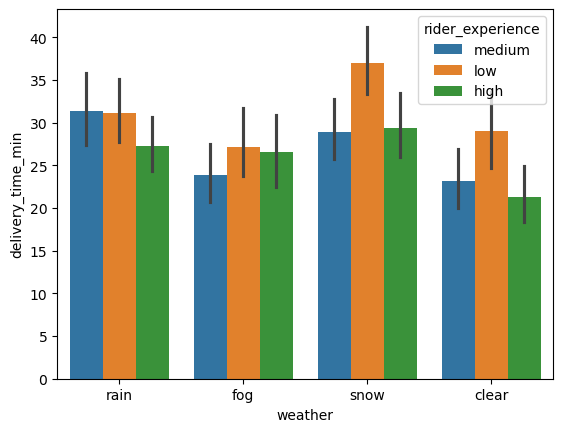

In [32]:
# 3. 날씨상태, 배달원 숙력도에 따른 배달시간의 차이 시각화 
sns.barplot(data=delivery_df, x='weather', y='delivery_time_min', hue='rider_experience')
답03 = 1

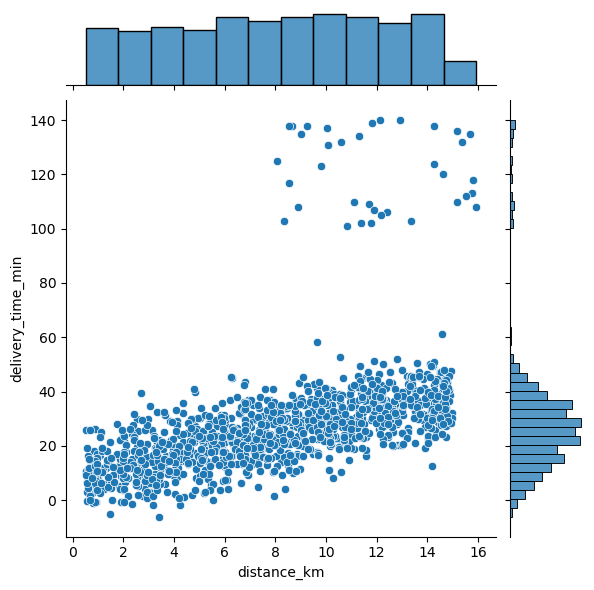

In [33]:
# 4 배달시간과 배달거리간 분석
sns.jointplot(data=delivery_df, x='distance_km', y='delivery_time_min')

In [34]:
# delivery_time이 100이상인 이상치 제거
print(delivery_df['delivery_time_min'].count()) #1200
result = (delivery_df['delivery_time_min'] >= 100)
print(result.sum()) #36
# delivery_df[result]
# delivery_df[result].index
del_df = delivery_df.drop(delivery_df[result].index, axis=0) #행 삭제
print(del_df['delivery_time_min'].count()) #1164
del_df.info()

1200
36
1164
<class 'pandas.core.frame.DataFrame'>
Index: 1164 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_amount       1128 non-null   float64
 1   num_items          1164 non-null   int64  
 2   distance_km        1164 non-null   float64
 3   rider_experience   1164 non-null   object 
 4   weather            1164 non-null   object 
 5   order_time         1164 non-null   object 
 6   promotion_applied  1164 non-null   object 
 7   delivery_time_min  1164 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 81.8+ KB


In [35]:
# 5. 이상치 제거
result = del_df['delivery_time_min'] < 0
print(del_df[result])
print(del_df[result].count())
print(del_df[result].index)
del_df.drop(del_df[result].index, axis=0, inplace=True)
print(del_df[result].index) #[]
del_df[result].reset_index(drop=True, inplace=True) #인덱스 초기화
del_df
del_df['delivery_time_min'].tail(10) 

      order_amount  num_items  distance_km rider_experience weather  \
110          14.65          7         0.57              low    rain   
283          45.93          5         0.94           medium   clear   
346          89.31          6         1.46             high   clear   
578          62.95          2         1.89             high     fog   
754          12.92          2         2.01             high   clear   
971            NaN          1         0.81             high   clear   
975          36.74          3         4.23             high   clear   
977          67.16          1         3.19           medium    rain   
1003         62.05          4         0.90             high   clear   
1061         12.19          6         3.42           medium     fog   
1194         57.46          5         2.34             high     fog   

     order_time promotion_applied  delivery_time_min  
110       night                 Y               -0.3  
283     evening                 Y    

C:\Users\LG\AppData\Local\Temp\ipykernel_21088\1334419143.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(del_df[result].index) #[]
C:\Users\LG\AppData\Local\Temp\ipykernel_21088\1334419143.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  del_df[result].reset_index(drop=True, inplace=True) #인덱스 초기화


1189    24.4
1190     8.2
1191    20.7
1192    27.4
1193    17.8
1195    19.4
1196    38.1
1197    42.1
1198    25.3
1199    15.6
Name: delivery_time_min, dtype: float64

In [36]:
# 6 칼럼 삭제 
del_df.drop(columns=['order_amount', 'num_items'], axis=1, inplace=True)
del_df

,distance_km,rider_experience,weather,order_time,promotion_applied,delivery_time_min
0,6.49,medium,rain,afternoon,N,26.5
1,9.17,low,fog,morning,N,26.4
2,11.80,low,fog,night,Y,37.1
3,10.67,high,snow,evening,N,45.0
4,5.81,high,snow,night,Y,20.0
...,...,...,...,...,...,...
1195,1.17,low,snow,night,N,19.4
1196,12.14,low,snow,morning,Y,38.1
1197,14.61,low,clear,evening,N,42.1
1198,7.37,low,fog,night,Y,25.3


In [37]:
# 7. 원-핫 인코딩 
cat_col = ['rider_experience', 'weather', 'order_time']
encoding_df = pd.get_dummies(data=del_df, columns=cat_col, drop_first=True)
encoding_df
encoding_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1153 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   distance_km              1153 non-null   float64
 1   promotion_applied        1153 non-null   object 
 2   delivery_time_min        1153 non-null   float64
 3   rider_experience_low     1153 non-null   bool   
 4   rider_experience_medium  1153 non-null   bool   
 5   weather_fog              1153 non-null   bool   
 6   weather_rain             1153 non-null   bool   
 7   weather_snow             1153 non-null   bool   
 8   order_time_evening       1153 non-null   bool   
 9   order_time_morning       1153 non-null   bool   
 10  order_time_night         1153 non-null   bool   
dtypes: bool(8), float64(2), object(1)
memory usage: 45.0+ KB


In [38]:
# 8. 레이블 인코딩 
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

encoding_df['promotion_applied'] = le.fit_transform(encoding_df['promotion_applied'])
encoding_df

,distance_km,promotion_applied,delivery_time_min,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
0,6.49,0,26.5,False,True,False,True,False,False,False,False
1,9.17,0,26.4,True,False,True,False,False,False,True,False
2,11.80,1,37.1,True,False,True,False,False,False,False,True
3,10.67,0,45.0,False,False,False,False,True,True,False,False
4,5.81,1,20.0,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1195,1.17,0,19.4,True,False,False,False,True,False,False,True
1196,12.14,1,38.1,True,False,False,False,True,False,True,False
1197,14.61,0,42.1,True,False,False,False,False,True,False,False
1198,7.37,1,25.3,True,False,True,False,False,False,False,True


In [39]:
# 9. 데이터 분리(학습용:테스트용) - 배달시간 예측 
from sklearn.model_selection import train_test_split

X = encoding_df.drop(columns='delivery_time_min', axis=1) #독립 변수
y = encoding_df['delivery_time_min'] #종속 변수 

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape, X_valid.shape, y_valid.shape)

(922, 10) (922,) (231, 10) (231,)


In [40]:
# 10. 스케일링 
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_valid)
print(X_train, X_test)

[[-0.56478555 -0.79853329 -0.64857316 ...  1.69527272 -0.60993755
  -0.55145429]
 [-1.71797432 -0.79853329  1.54184609 ... -0.58987559 -0.60993755
  -0.55145429]
 [-1.6914365  -0.79853329 -0.64857316 ...  1.69527272 -0.60993755
  -0.55145429]
 ...
 [-0.19566865 -0.79853329  1.54184609 ...  1.69527272 -0.60993755
  -0.55145429]
 [ 0.49190206 -0.79853329 -0.64857316 ...  1.69527272 -0.60993755
  -0.55145429]
 [ 0.83448115  1.25229594 -0.64857316 ... -0.58987559 -0.60993755
  -0.55145429]] [[ 0.25788677 -0.79853329  1.54184609 ... -0.58987559 -0.60993755
  -0.55145429]
 [-0.35730808 -0.79853329 -0.64857316 ... -0.58987559 -0.60993755
  -0.55145429]
 [ 0.97923288  1.25229594  1.54184609 ... -0.58987559  1.63951212
  -0.55145429]
 ...
 [-0.7867382   1.25229594  1.54184609 ... -0.58987559  1.63951212
  -0.55145429]
 [ 0.05523435  1.25229594 -0.64857316 ... -0.58987559 -0.60993755
  -0.55145429]
 [-1.43088339 -0.79853329  1.54184609 ... -0.58987559  1.63951212
  -0.55145429]]


In [41]:
# 11. 선형회귀 모델 
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
# 성능 평가
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. 테스트 데이터로 예측 수행
y_pred = lr.predict(X_test)
print(y_pred)

# 2. 지표 계산
mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_valid, y_pred)
r2 = r2_score(y_valid, y_pred)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

[33.04489551 19.52892231 37.47629596 25.20974623 18.01871403 34.99240634
 21.75807544 21.29733239 32.94719308 27.82904916  8.38470199 16.16406261
 27.72133427 20.17910389 32.90124702 27.37019434 25.43323565 15.60667932
 22.52610277 25.50114134 38.40111935 31.34170732 30.96377328 34.27795988
 11.26278493 33.13753971 16.00328814 19.04747684 33.88198512 16.06926004
 25.16284376 11.37144479 36.4179375  34.7014118  22.04489525 20.0678347
 13.84877083 15.83599074 13.97711394 35.78762375 30.61660151 17.11435067
 23.43535811 33.16560986 35.53892226 23.05296333 22.97081323 32.88180173
 29.1209891  13.64181808 36.6023636  22.42810852 13.92341239 30.52577603
 16.36528366 16.77498313 16.92024026 13.07279682 30.05143083 32.05254138
 32.66896448 21.24699523 28.79563126 32.66838401 16.59353412 27.10043326
 32.40550582 30.91396341 13.73606293 19.97403786 36.66901215 13.98653241
 27.49908165 21.12599241 14.76400158 38.97506538 16.14799762 25.96782835
 20.4423694  28.17906442 33.68953814 17.10302183  8.

In [ ]:
# 12. 랜덤포레스트 모델
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(X_train, y_train)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization

tf.random.set_seed(42)

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam',
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, epochs=50, batch_size=128,
         validation_data=(X_test, y_valid))

In [ ]:
# 14. 과적합 방지 
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

model_checklpoint = ModelCheckpoint(
    monitor='val_loss',
    save_best_only=True,
    filepath = 'best_model.h5',
    verbose = 1)

model.fit(X_train, y_train,
          epochs = 50,
          batch_size = 128,
          validation_data = (X_test, y_valid),
          callbacks = [early_stopping, model_checklpoint])